# Usar panel de Saavedra & Romero 2021

# Paquetes

In [2]:
import pandas as pd

# Cargar datos

In [35]:
panel_SR2021 = pd.read_stata("../../Data/14_Saavedra_Romero_2021/SR_2021/CreatedData/panel_final.dta",
                            convert_categoricals=False)
panel_SR2021_minerales = pd.read_stata("../../Data/14_Saavedra_Romero_2021/SR_2021/CreatedData/Temporary/panel_prillegalMi.dta")

C:\Users\jcalf\AppData\Local\Temp\ipykernel_16192\3136415554.py:1: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  panel_SR2021 = pd.read_stata("../../Data/14_Saavedra_Romero_2021/SR_2021/CreatedData/panel_final.dta",
C:\Users\jcalf\AppData\Local\Temp\ipykernel_16192\3136415554.py:1: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  panel_SR2021 = pd.read_stata("../../Data/14_Saavedra_Romero_2021/SR_2021/CreatedData/panel_final.dta",
C:\Users\jcalf\AppData\Local\Temp\ipykernel_16192\3136415554.py:1: Unicode

# Replicar datos de tablas de SR2021
Sigo la semántica de la primera regresión de SR2021 que está en _SR_2021\Stata\04_DiDCountries.do_

## Tabla 3 SR2021

### Tabla 3 - Panel A
A partir del código de Stata en _SR_2021\Stata\06_DiD_Mineral.do_ reproduzco datos de Colombia en la tabla 3 de SR2021

In [43]:
# Reproducir procesamiento del dofile

# Preprocesamiento en Lineas 4-7 del dofile
panel_SR2021_minerales['ind_gold'] = panel_SR2021_minerales['mineral']==1
panel_SR2021_minerales.loc[panel_SR2021_minerales['ano']>=2011, 'ind_after'] = 1
panel_SR2021_minerales['afterxgold'] = panel_SR2021_minerales['ind_after'] * panel_SR2021_minerales['ind_gold']

# Conservar solo las observaciones de minerales 1,4 (línea 17 del dofile)
panel_SR2021_minerales = panel_SR2021_minerales[panel_SR2021_minerales['mineral'].isin([1,4])]


In [47]:
panel_SR2021_minerales['propmined_illegal_mi']

13              NaN
16        98.148796
20              NaN
21              NaN
24        97.470055
            ...    
132100          NaN
132102          NaN
132107          NaN
132109          NaN
132120          NaN
Name: propmined_illegal_mi, Length: 24024, dtype: float32

In [49]:
display(panel_SR2021_minerales.groupby(['mineral', 'ind_after'])['propmined_illegal_mi']
        .agg(['mean', 'std']))

mean        std
mineral ind_after                      
1       0.0        88.674263  24.751994
        1.0        83.945206  26.213501
4       0.0        85.073524  26.753930
        1.0        79.876694  27.850871

- Los valores de Colombia son los mismos mostrados en el recuadro verde de la tabla 3 de SR2021 para Carbón y oro
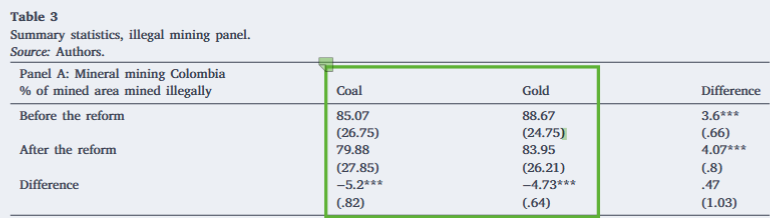

### Tabla 3 - Panel B
A partir del código de Stata en _SR_2021\Stata\04_DiDCountries.do_ reproduzco datos de Colombia en la tabla 3 de SR2021

In [32]:
# Nombres de las variables relevantes

# Variables dependientes
variable_y = 'propmined_illegal'

# Variables independientes
# ind_after es dummy si la observación es despues de 2011
# ind_col es dummy=1 si la observación es de un municipios de Colombia
variables_x = ['ind_after', 'ind_col', 'after_x_col']

# Organizar las variables consideradas
variables_modelo = [variable_y] + variables_x

# Calcular estadísticas de porcentaje de area minada ilegalmente
display(panel_SR2021[variables_modelo].groupby(['ind_col', 'ind_after'])[variable_y]
        .agg(['mean', 'std']))

mean        std
ind_col ind_after                      
0.0     0.0        87.646980  21.538476
        1.0        77.221359  27.081739
1.0     0.0        88.503593  23.403005
        1.0        82.329659  25.554259

- Los valores de Colombia son los mismos mostrados en el recuadro verde de la tabla 3 de SR2021
- Los valores de Perú no coinciden. Esto no es un problema porque solo voy a suar los valores de Colombia

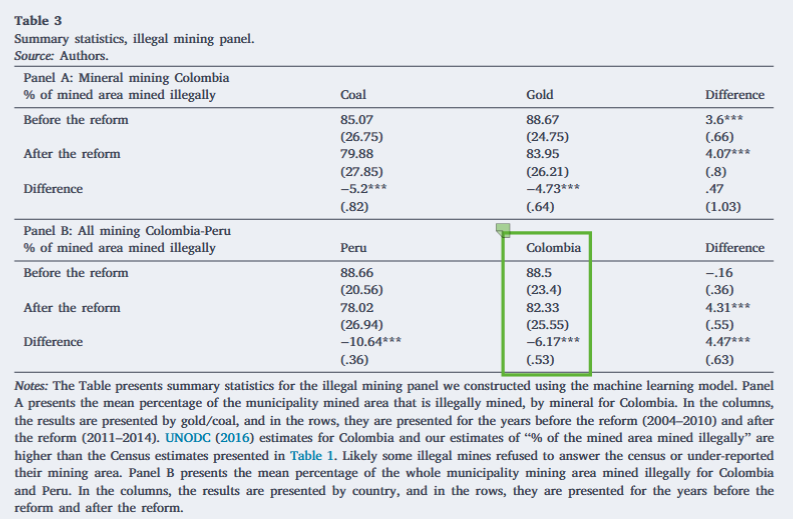